In [2]:
%pip install pandas numpy scikit-learn matplotlib

  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-macosx_10_9_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp310-cp310-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 32.2 MB/s  0:00:00 eta 0:00:01
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp310-cp310-macosx_10_9_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp310-cp310-macosx_11_0_arm64.whl (63 kB)
Using cached pillow-12.2.0-cp310-cp310-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

## Task: Predict whether or not a text is a type of cyberbullying

In [14]:
data = pd.read_csv('cyberbullying_tweets.csv')
data.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


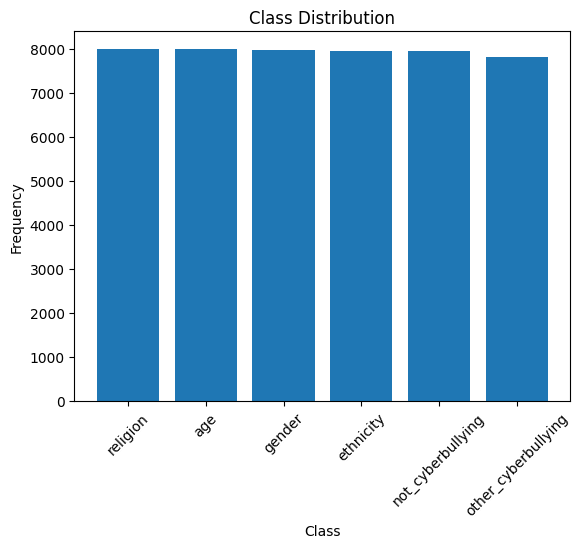

In [15]:
# Frequency of each class

class_counts = data['cyberbullying_type'].value_counts()
plt.bar(class_counts.index, class_counts.values)
plt.xlabel('Class')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.title('Class Distribution')
plt.show()

In [16]:
# Encode cyberbullying_type as multi-class labels
data['cyberbullying_type_code'] = data['cyberbullying_type'].astype('category').cat.codes
data.head()

,tweet_text,cyberbullying_type,cyberbullying_type_code
0,"In other words #katandandre, your food was cra...",not_cyberbullying,3
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying,3
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying,3
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying,3
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying,3


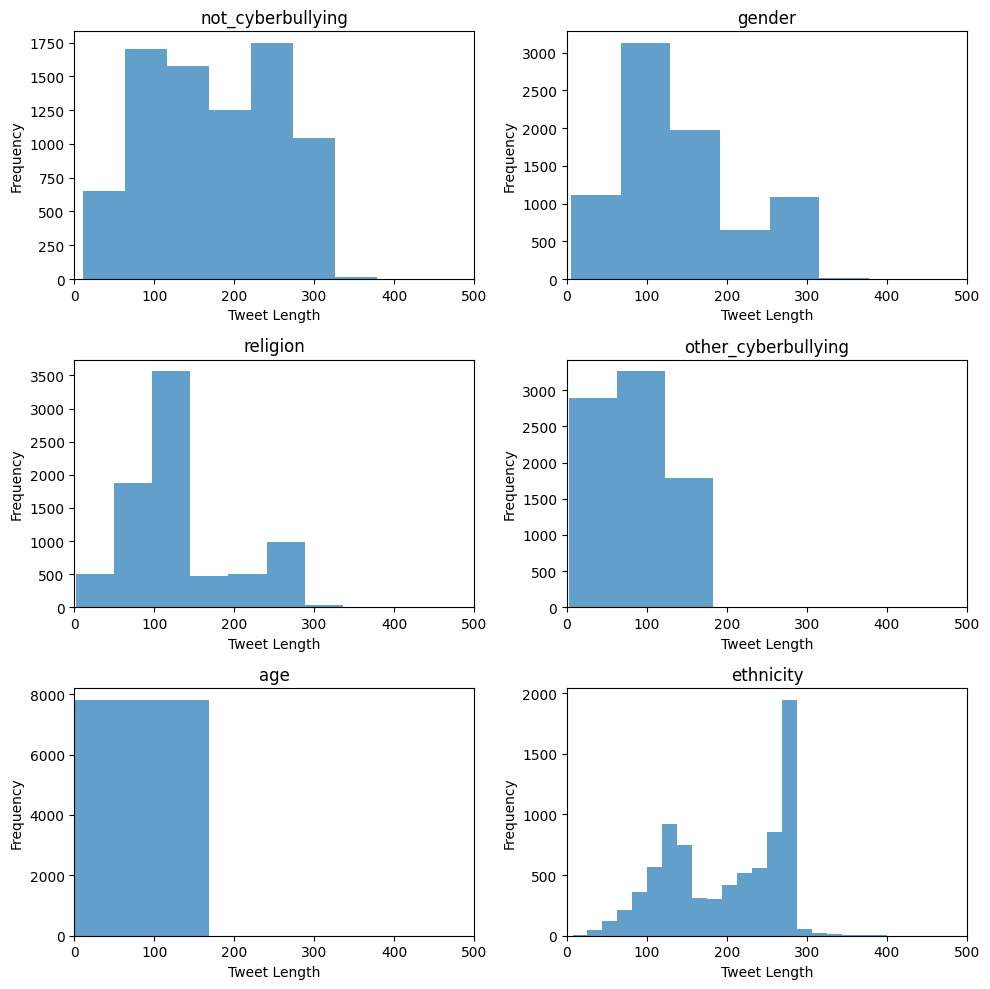

In [20]:
# Distribution of tweet lengths for each class
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

for i, cyberbullying_type in enumerate(data['cyberbullying_type'].unique()):
    ax = axes[i // 2, i % 2]
    subset = data[data['cyberbullying_type_code'] == i]
    tweet_lengths = subset['tweet_text'].apply(len)
    ax.hist(tweet_lengths, bins=30, alpha=0.7)
    ax.set_title(cyberbullying_type)
    ax.set_xlabel('Tweet Length')
    ax.set_xbound(0, 500)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [22]:
all_words = []
not_cyberbullying_words = []
gender_words = []
religion_words = []
other_cyberbullying_words = []
age_words = []
ethnicity_words = []

for idx, row in data.iterrows():
    tokens = row['tweet_text']
    all_words.extend(tokens)
    if row['cyberbullying_type'] == 'not_cyberbullying':
        not_cyberbullying_words.extend(tokens)
    elif row['cyberbullying_type'] == 'gender':
        gender_words.extend(tokens)
    elif row['cyberbullying_type'] == 'religion':
        religion_words.extend(tokens)
    elif row['cyberbullying_type'] == 'other_cyberbullying':
        other_cyberbullying_words.extend(tokens)
    elif row['cyberbullying_type'] == 'age':
        age_words.extend(tokens)
    elif row['cyberbullying_type'] == 'ethnicity':
        ethnicity_words.extend(tokens)

unique_all = len(set(all_words))
unique_not_cyberbullying = len(set(not_cyberbullying_words))
unique_gender = len(set(gender_words))
unique_religion = len(set(religion_words))
unique_other_cyberbullying = len(set(other_cyberbullying_words))
unique_age = len(set(age_words))
unique_ethnicitiy = len(set(ethnicity_words))

print(f"Overall unique words: {unique_all}")
print(f"Not cyberbullying unique words: {unique_not_cyberbullying}")
print(f"Gender unique words: {unique_gender}")
print(f"Religion unique words: {unique_religion}")
print(f"Other cyberbullying unique words: {unique_other_cyberbullying}")
print(f"Age unique words: {unique_age}")
print(f"Ethnicity unique words: {unique_ethnicitiy}")
print(f"Unique words only in cyberbullying: {len(set(all_words) - set(not_cyberbullying_words))}")
print(f"Unique words only in not cyberbullying: {len(set(all_words) - set(gender_words) - set(religion_words) - set(other_cyberbullying_words) - set(age_words) - set(ethnicity_words))}")

Overall unique words: 806
Not cyberbullying unique words: 426
Gender unique words: 247
Religion unique words: 243
Other cyberbullying unique words: 263
Age unique words: 301
Ethnicity unique words: 209
Unique words only in cyberbullying: 380
Unique words only in not cyberbullying: 155


In [26]:
not_cyberbullying_freq = Counter(not_cyberbullying_words)
gender_freq = Counter(gender_words)
religion_freq = Counter(religion_words)
other_cyberbullying_freq = Counter(other_cyberbullying_words)
age_freq = Counter(age_words)
ethnicity_freq = Counter(ethnicity_words)

# Top words in spam and ham
top_15_not_cyberbullying = not_cyberbullying_freq.most_common(15)
top_15_gender = gender_freq.most_common(15)
top_15_religion = religion_freq.most_common(15)
top_15_other_cyberbullying = other_cyberbullying_freq.most_common(15)
top_15_age = age_freq.most_common(15)
top_15_ethnicity = ethnicity_freq.most_common(15)

not_cyberbullying_only_words = set(all_words) - set(gender_words) - set(religion_words) - set(other_cyberbullying_words) - set(age_words) - set(ethnicity_words)
cyberbullying_only_words = set(all_words) - set(not_cyberbullying_words)

not_cyberbullying_only_freq = {word: not_cyberbullying_freq[word] for word in not_cyberbullying_only_words}
gender_only_freq = {word: gender_freq[word] for word in cyberbullying_only_words}
religion_only_freq = {word: religion_freq[word] for word in cyberbullying_only_words}
other_cyberbullying_only_freq = {word: other_cyberbullying_freq[word] for word in cyberbullying_only_words}
age_only_freq = {word: age_freq[word] for word in cyberbullying_only_words}

In [29]:
print("=" * 50)
print("TOP 15 WORDS IN NOT CYBERBULLYING:")
print("=" * 50)
for word, count in top_15_not_cyberbullying:
    print(f"{word}: {count} ({count/len(not_cyberbullying_words)*100:.2f}%)")

TOP 15 WORDS IN NOT CYBERBULLYING:
 : 100974 (15.29%)
e: 50710 (7.68%)
t: 40609 (6.15%)
a: 40003 (6.06%)
o: 38245 (5.79%)
i: 31634 (4.79%)
n: 30733 (4.65%)
s: 29152 (4.42%)
r: 25968 (3.93%)
l: 22880 (3.47%)
h: 22335 (3.38%)
u: 15861 (2.40%)
d: 15693 (2.38%)
m: 13786 (2.09%)
c: 13146 (1.99%)


In [30]:
print("=" * 50)
print("TOP 15 WORDS IN GENDER:")
print("=" * 50)
for word, count in top_15_gender:
    print(f"{word}: {count} ({count/len(gender_words)*100:.2f}%)")

TOP 15 WORDS IN GENDER:
 : 180184 (16.57%)
e: 93406 (8.59%)
a: 71941 (6.61%)
t: 66452 (6.11%)
o: 62523 (5.75%)
s: 53480 (4.92%)
i: 51070 (4.70%)
n: 51039 (4.69%)
r: 40840 (3.75%)
h: 34671 (3.19%)
l: 34361 (3.16%)
u: 25168 (2.31%)
d: 24178 (2.22%)
m: 23578 (2.17%)
y: 22877 (2.10%)


In [31]:
print("=" * 50)
print("TOP 15 WORDS IN RELIGION:")
print("=" * 50)
for word, count in top_15_religion:
    print(f"{word}: {count} ({count/len(religion_words)*100:.2f}%)")

TOP 15 WORDS IN RELIGION:
 : 259610 (16.39%)
e: 118801 (7.50%)
a: 102779 (6.49%)
t: 100531 (6.35%)
i: 99588 (6.29%)
o: 93401 (5.90%)
s: 83895 (5.30%)
n: 77575 (4.90%)
r: 74142 (4.68%)
h: 57276 (3.62%)
l: 54239 (3.43%)
u: 44185 (2.79%)
d: 43334 (2.74%)
m: 38024 (2.40%)
c: 27879 (1.76%)


In [33]:
print("=" * 50)
print("TOP 15 WORDS IN OTHER CYBERBULLYING:")
print("=" * 50)
for word, count in top_15_other_cyberbullying:
    print(f"{word}: {count} ({count/len(other_cyberbullying_words)*100:.2f}%)")

TOP 15 WORDS IN OTHER CYBERBULLYING:
 : 102648 (15.31%)
e: 52584 (7.84%)
t: 44914 (6.70%)
a: 37908 (5.65%)
o: 37666 (5.62%)
i: 33231 (4.96%)
n: 30869 (4.60%)
s: 29993 (4.47%)
r: 25142 (3.75%)
h: 22873 (3.41%)
l: 22198 (3.31%)
u: 16023 (2.39%)
d: 15557 (2.32%)
m: 13464 (2.01%)
c: 13140 (1.96%)


In [34]:
print("=" * 50)
print("TOP 15 WORDS IN AGE:")
print("=" * 50)
for word, count in top_15_age:
    print(f"{word}: {count} ({count/len(age_words)*100:.2f}%)")

TOP 15 WORDS IN AGE:
 : 250676 (18.07%)
e: 114924 (8.29%)
o: 87385 (6.30%)
t: 80456 (5.80%)
i: 76196 (5.49%)
a: 73335 (5.29%)
l: 69853 (5.04%)
s: 67870 (4.89%)
h: 67282 (4.85%)
n: 61786 (4.45%)
r: 51011 (3.68%)
d: 39798 (2.87%)
u: 36698 (2.65%)
g: 30689 (2.21%)
c: 29027 (2.09%)


In [35]:
print("=" * 50)
print("TOP 15 WORDS IN ETHNICITY:")
print("=" * 50)
for word, count in top_15_ethnicity:
    print(f"{word}: {count} ({count/len(ethnicity_words)*100:.2f}%)")

TOP 15 WORDS IN ETHNICITY:
 : 190162 (17.15%)
e: 79794 (7.19%)
t: 62396 (5.63%)
a: 61276 (5.52%)
o: 56366 (5.08%)
i: 53637 (4.84%)
n: 50336 (4.54%)
s: 49463 (4.46%)
r: 40325 (3.64%)
h: 35682 (3.22%)
u: 35227 (3.18%)
l: 32701 (2.95%)
g: 28885 (2.60%)
d: 28230 (2.55%)
c: 25703 (2.32%)


In [36]:
print("=" * 18)
print("NOT CYBERBULLYING WORDS")
print("=" * 18)
top_spam_specific = sorted(not_cyberbullying_only_freq.items(), key=lambda x: x[1], reverse=True)[:15]
for word, count in top_spam_specific:
    print(f"{word}: {count}")

NOT CYBERBULLYING WORDS
ã: 125
›: 71
É: 17
ë: 13
̩: 12
😍: 11
パ: 10
😱: 8
い: 7
🙅: 7
く: 6
😏: 6
⌣: 6
🐧: 6
ô: 6
